# **<p style="letter-spacing: 1.5px; color:#4d4d4d; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #4d4d4d">INTRODUCTION</p>**

In this notebook based on the kaggle playground series 4, episode 9, we predict car prizes of used cars. Challenging are the price outliers in combination with the RMSE metric, which is sensitive to outliers.

><div style= "background: #e6e6e6;">🎉This notebooks contains two models which were a substantial part of the winning solution, namely the model LGBM5 and the CatBoostClassifier. These models were inserted together with an SVM into [the neural network](https://www.kaggle.com/code/yekenot/ps-s4-e9-deeptables-nn-starter)  provided by [Vladimir Demidov](https://www.kaggle.com/yekenot). All models were trained on 20 folds, the single models were additionally trained on 5 bags using the stratification shown in this notebook.</div>

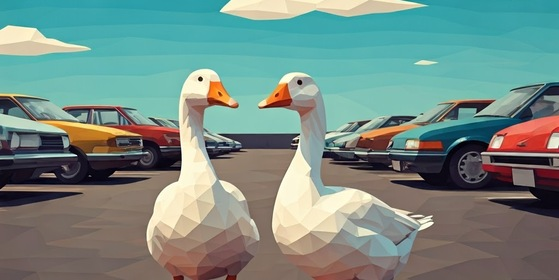

In [ ]:
import numpy as np
import pandas as pd
import datetime
import shap
import random
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error,roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge

from category_encoders import TargetEncoder

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.svm import LinearSVR, SVR
#from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [ ]:
seed = 42
VER=7
n_folds = 5
n_bags = 3
TESTRUN = False

## **<span style="color:#2b0408;">Versions</span>**

* Version 1: CatBoost
* Version 2+3: LinearSVR
* Version 4: Ensembling
* Version 5: Adding LGBM
* Version 6: Adding NN
* Version 7: Changing CatBoost to a Classifier, adding two LGBMs, adding original data

# **<p style="letter-spacing: 1.5px; color:#4d4d4d; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #4d4d4d">PREPROCESSING</p>**

In this section the data are imported, analyzed, visualized and preprocessed. The preprocessing happens in a preprocessing function at the end of the section.

## **<span style="color:#2b0408;">Import Data</span>**

In [ ]:
df_train=pd.read_csv("/kaggle/input/playground-series-s4e9/train.csv", index_col=0)
df_original = pd.read_csv("/kaggle/input/used-car-price-prediction-dataset/used_cars.csv")
df_test=pd.read_csv("/kaggle/input/playground-series-s4e9/test.csv", index_col=0)
sample_sub=pd.read_csv("/kaggle/input/playground-series-s4e9/sample_submission.csv")

#clean original columns
df_original[['milage', 'price']] = df_original[['milage', 'price']].map(
    lambda x: int(''.join(re.findall(r'\d+', x))))

#prepare dataframes for the oof and test predictions:
oof_df = pd.read_csv("/kaggle/input/playground-series-s4e9/train.csv")[["id"]]
test_df = pd.read_csv("/kaggle/input/playground-series-s4e9/test.csv")[["id"]]

In [ ]:
if TESTRUN:
    df_train = df_train.sample(frac=0.2, random_state=seed)
    df_original = df_original.sample(frac=0.2, random_state=seed)
    oof_df = oof_df.sample(frac = 0.2, random_state = seed)

## **<span style="color:#2b0408;">Description</span>**

### **<span style="color:#999999;">Amount of Data</span>**

In [ ]:
print("Number of entries in training data:",len(df_train))
print("Number of entries in test data:",len(df_test))
print("Number of columns in training data:",len(df_train.columns))
print("Number of columns in test data:",len(df_test.columns))
print("Columns in training data:", df_train.columns)

### **<span style="color:#999999;">First samples</span>**

In [ ]:
df_train.head()

On first look the features seem to be very complex and are an invitation to feature engineering. As these features are generated synthetically, even when based on real world samples, not all real world connections are preserved. This is also emphasized in various discussion topics as [less feature engineering](https://www.kaggle.com/competitions/playground-series-s4e9/discussion/531766).

### **<span style="color:#999999;">Data Types</span>**

In [ ]:
df_train.info()

There are missing values for the features *fuel_type*, *accident* and *clean_title*, which we fill with "no_entry". The numerical columns are already encoded as integers. The types of the categorical values need to be changed. The only binary categorical feature is *clean_title*, which can be converted to integer. *model_year* is an ordinal variable which we leave as integer, but can be used as categorical variable later on.

In [ ]:
cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 
            'int_col', 'accident']
num_cols = ['model_year', 'milage']

### **<span style="color:#999999;">Duplicates</span>**

In [ ]:
feature_cols = df_test.columns.to_list()
print("Number of duplicates in train data:", len(df_train[df_train[feature_cols].duplicated()]), "\n")
print("Number of duplicates in test data:", len(df_test[df_test.duplicated()]), "\n")

The missing values are equally distributed in train and test data. There are no duplicates.

## **<span style="color:#2b0408;">EDA</span>**

The following table shows the number of unique values in each of the features and the mean, min and max number of occurences of the values.

In [ ]:
feat_stat = {}
for feature in df_train.columns:
    feat_stat[feature] = np.round(df_train[
        feature].value_counts().describe())[['count','mean', 'min', 'max']].astype(int)
feat_stat_df = pd.DataFrame(feat_stat)
feat_stat_df.T.sort_values(by=['count'])

### **<span style="color:#999999;">Target</span>**

There are only 25109 different price values. This means we can stratify for price.

In [ ]:
print(df_train['price'].value_counts().sort_index().to_string())

In [ ]:
print(len(df_train['price'].value_counts().to_string()))

In [ ]:
ax = sns.kdeplot(df_train['price'], color='orange', fill=True, log_scale=True)
ax.set(xlabel='log price');

The logarithmic price is roughly normally distributed. This is a challenge, as the metric is RMSE, which punishes outliers strongly. When we stratify for price we ensure that high prices are present in the validation data.

### **<span style="color:#999999;">Categorical Features</span>**

The mean goal of this analysis is to see how certain categories of each categorical variable are related to the price. Before we start with analyzing the categorical features we define a small helper function which displays the count as well as the mean and medium prices for the unique categories of a feature.

In [ ]:
def display_categories(df, feature, sort_feature='median price'):
    """
    displays the full list of categories of a categorical feature together with their
    properties count and mean and median price for each category
    """
    mean_price_per_category = np.round(df_train.groupby(feature)[
        'price'].mean()).reset_index().rename(columns={'price': 'mean price'})
    median_price_per_category = df_train.groupby(feature)[
        'price'].median().reset_index().rename(columns={'price': 'median price'})
    category_counts = pd.DataFrame(df_train[feature].value_counts())
    merger = pd.merge(mean_price_per_category, category_counts, on=feature)
    merger = pd.merge(median_price_per_category,merger, on = feature).sort_values(by=sort_feature)
    print(merger.to_string(index = False))
    return merger

The features *engine* and *model* contain a lot of categories with some of them only occuring a few times. Moreover it is to be expected that new categories are present in the test data. We use the code snippet from the excellent notebook [NN Starter](https://www.kaggle.com/code/cdeotte/nn-starter-lb-72300-cv-72800/notebook) of [cdoette](https://www.kaggle.com/cdeotte)

In [ ]:
for c in cat_cols + ['model_year','milage']:
    # compare test and train cat values
    A=df_train[c].astype('str').unique()
    B=df_test[c].astype('str').unique()
    C = np.setdiff1d(B,A)
    print(f"{c}: Test has categories {C} which are not in train.")
    if len(C)>0:
        print(f" => {len(df_test.loc[df_test[c].astype(str).isin(C)])} rows" )
        
    # RELABEL UNSEEN TEST VALUES AS ZERO
    #test.loc[test[c].isin(C),c] = 0 



As these are very few new categories and samples, we will leave it to the models to deal with the unseen categories. When we want to include *milage* as categorical feature, we need to round the values, such that train and test data categories are more similar. 

We now have a look at each feature separately. 

#### <span style="color:#999999;">accident</span>

In [ ]:
merger = display_categories(df_train, 'accident')

In [ ]:
sns.set(rc={'figure.figsize': (20, 5)})
mean_price_order = df_train.groupby('accident')['price'].median().sort_values().index
sns.boxplot(y=df_train['accident'], x=df_train['price'], palette='Set2',
           order=mean_price_order) 
plt.xscale('log')

#### <span style="color:#999999;">fuel_type</span>

In [ ]:
merger = display_categories(df_train, 'fuel_type')

In [ ]:
sns.set(rc={'figure.figsize': (20, 7)})
mean_price_order = df_train.groupby('fuel_type')['price'].median().sort_values().index
sns.boxplot(y=df_train['fuel_type'], x=df_train['price'], palette='Set2',
           order=mean_price_order) 
plt.xscale('log')

The categories *not supported* and *–* are very similar in terms of median price and since *no supported* has only 15 samples we summarize the categories .

#### <span style="color:#999999;">transmission</span>

In [ ]:
display_categories(df_train, 'transmission')

In [ ]:
sns.set(rc={'figure.figsize': (20, 20)})
median_price_order = df_train.groupby('transmission')['price'].median().sort_values().index
sns.boxplot(y=df_train['transmission'], x=df_train['price'], palette='Set2',
           order=median_price_order) 
plt.xscale('log')

#### <span style="color:#999999;">brand</span>

In [ ]:
display_categories(df_train, 'brand')

In [ ]:
sns.set(rc={'figure.figsize': (20, 20)})
mean_price_order = df_train.groupby('brand')['price'].median().sort_values().index
ax = sns.boxplot(y=df_train['brand'], x=df_train['price'], palette='Set2',
           order=mean_price_order) 
plt.xscale('log')

It is tempting to pull out some of the brand categories with high mean price and present them to the model as luxury brands. But there are large differences between median and mean price and brands with a high median price do not necessarily have a large mean price and the other way round, because of the many outliers in price. This can be better observed in the following scatter plots. Building a feature on the price means could lead to overfitting and should therefore be done within the crossvalidation. I will not attempt to build a luxury feature.

#### <span style="color:#999999;">int_col</span>

In [ ]:
merger = display_categories(df_train, 'int_col')

In [ ]:
sns.scatterplot(x=merger['mean price'], y=merger['median price'],
                color='grey', s = 100)

def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        if point['x'] > 150000:
            ax.text(point['x']+.02, point['y'], str(point['val']))

label_point(merger['mean price'], merger['median price'], merger['int_col'], plt.gca()) 

plt.show()

#### <span style="color:#999999;">ext_col</span>

In [ ]:
merger = display_categories(df_train, 'ext_col')

In [ ]:
sns.scatterplot(x=merger['mean price'], y=merger['median price'],
                color='grey', s = 100)


label_point(merger['mean price'], merger['median price'], merger['ext_col'], plt.gca()) 

plt.show()

#### <span style="color:#999999;">engine</span>

In [ ]:
merger = display_categories(df_train, 'engine')

In [ ]:
sns.set(rc={'figure.figsize': (20, 20)})
sns.scatterplot(x=merger['mean price'], y=merger['median price'],
                color='grey', s = 100)

label_point(merger['mean price'], merger['median price'], merger['engine'], plt.gca()) 

plt.show()

#### <span style="color:#999999;">model</span>

In [ ]:
merger = display_categories(df_train, 'model')

In [ ]:
sns.set(rc={'figure.figsize': (20, 17)})
sns.scatterplot(x=merger['mean price'], y=merger['median price'],
                color='grey', s = 100)

label_point(merger['mean price'], merger['median price'], merger['model'], plt.gca()) 

plt.show()

### **<span style="color:#999999;">Numerical Features</span>**

Upon examining the boxplots for the numerical features and comparing them with the test data, it can be observed that the distributions between the training and test datasets are similar, which is a common occurrence in playground datasets. 

In [ ]:
sns.set(rc={'figure.figsize': (20, 5)})
df_train[num_cols].hist(color = "grey")
plt.suptitle('Train Data', y=1.02)
df_test[num_cols].hist(color = "orange")
plt.suptitle('Test Data', y=1.02)
plt.show()

As suggested by [cdoette](https://www.kaggle.com/cdeotte) in the [discussion](https://www.kaggle.com/competitions/playground-series-s4e9/discussion/532952) we use boxplots to visualize the connection between numerical columns and price instead of scatterplots. Boxes with few samples (<= 500), where the median is thus not robust, are colored in orange.

#### <span style="color:#999999;">milage</span>

In [ ]:
def set_boxplot_color(x):
    colors = []
    for bin in x.value_counts().index:
        count = x.value_counts()[bin]
        color = 'orange' if count > 500 else 'grey'
        colors.append(color)
    return colors

sns.set(rc={'figure.figsize': (20, 5)})
milage2 = (df_train.milage//10_000)*10_000
colors = set_boxplot_color(milage2)
sns.boxplot(x=milage2, y=df_train['price'], palette = colors)
plt.ylim((0,100_000))
plt.xticks(rotation=45)
plt.show()

The price drops with milage. *fuel_type* explains part of the variation of the relation between milage and price: The price of *hybrid* cars does not depend on mileage.

In [ ]:
sns.scatterplot(x=df_train[df_train['fuel_type'] != 'Gasoline']['price'], 
                y=df_train[df_train['fuel_type'] != 'Gasoline']['milage'],
                hue = df_train[df_train['fuel_type'] != 'Gasoline']['fuel_type'],
                color='grey', alpha=0.5)
plt.xscale('log')

#### <span style="color:#999999;">model_year</span>

In [ ]:
#sns.scatterplot(x=df_train['price'], y=df_train['model_year'],
#                color='grey', alpha=0.5, s = 3)
#plt.xscale('log')

colors = set_boxplot_color(df_train['model_year'])
sns.set(rc={'figure.figsize': (20, 5)})
sns.boxplot(x=df_train['model_year'], y=df_train['price'], palette = colors)
plt.ylim((0,100_000))
plt.xticks(rotation=45)
plt.show()

The price rises with model year with the exception of model year 1974.

## **<span style="color:#2b0408;">Feature Engineering</span>**

We introduce only a few new features, as most public features do not contribute to an improvement in crossvalidation score.

In [ ]:
def feat_eng(data):
    #categorical features
    cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 
                'int_col', 'accident']
    df = data.copy()
    for feature in ['fuel_type', 'accident', 'clean_title']:
        df[feature] = df[feature].fillna("no_entry")
    df['clean_title'] = np.where(df['clean_title']== 'Yes',1,0).astype('int16')
    df['fuel_type'] = df['fuel_type'].replace({'–':'not supported'})
    df['mileage'] = df['milage']//100
    for feature in cat_cols:
        df[feature] = df[feature].astype('category')
    #numerical features
    df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype('float').fillna(-1)
    df['displacement'] = df['engine'].str.extract(r'(\d+(\.\d+)?)L')[0].astype(float).fillna(-1)
    return df

In [ ]:
feat_cols = df_test.columns.to_list()
data_concat = feat_eng(pd.concat([df_train[feat_cols], df_original[feat_cols], df_test]))
data_train = data_concat[:len(df_train)]
data_train['price']=df_train['price']
data_original = data_concat[len(df_train):len(df_train)+len(df_original)]
data_original['price'] = df_original['price']
data_test = data_concat[len(df_train)+len(df_original):]
cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 
                'int_col', 'accident', 'model_year','mileage', 
           ]
num_cols = ['milage', 'horsepower', 'displacement']

# **<p style="letter-spacing: 1.5px; color:#4d4d4d; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #4d4d4d">MODELING</p>**

## **<span style="color:#2b0408;">Cross Validation</span>**

To make the result compatible with other's works, we do not use a repeated crossvalidation, but average over bags with different model seeds and shuffled column order. Both contribute individually to a different result, making the model more robust after averaging. We stratify for price during crossvalidation. In this way we guarantee that each model produced in each bag/fold is confronted with outlier prices which hopefully reflect the price structure of the test data.

### **<span style="color:#999999;">Cross Validation Function</span>**

In [ ]:
def crossvalidate(label, data, test_data, n_bags = 5, n_splits = 5):
    
        start_time = datetime.datetime.now()
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        
        # Initialize lists to store models and cv scores
        scores = []
        weights = []
        shap_values = 0
        feat_scores = 0
        test_pred = np.zeros(len(test_data))
        oof = np.zeros(len(data))
        X_test = test_data
        y = data['price'].astype(float)
        
        # Perform cross-validation
        for fold, (train_index, valid_index) in enumerate(cv.split(data, y.astype(str))):
            
            # Split the data into training and validation sets for the current fold
            X_train, X_valid = data.iloc[train_index], data.drop(columns = "price").iloc[valid_index]
            y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
            
            if label == "CAT":
                X_train = pd.concat([X_train, data_original2,data_original2], axis=0)
                y_train = pd.concat([y_train,data_original2['price'],data_original2['price'],
                                ]
                                ,axis = 0)
                X_train, X_valid, X_test_temp = target_encoding(X_train,X_valid, X_test, cat_cols)
            if label == "LGBM":
                X_train = pd.concat([X_train, data_original,data_original], axis=0)
                y_train = pd.concat([y_train,data_original['price'],data_original['price'],
                                ]
                                ,axis = 0)
            
            X_train = X_train.drop(columns = ['price'])
            
            if label != "CAT":
                X_test_temp = X_test
            
            #to get variation in bags we shuffle columns and change seeds
            for i in range(n_bags):
            
                cols_temp = X_train.columns.to_list()
                random.Random(i).shuffle(cols_temp)
                X_train = X_train[cols_temp]
                X_test_temp = X_test_temp[cols_temp]
                X_valid = X_valid[cols_temp]
                
                # Train the model
                
                if label == "CAT":
                    m = clone(model)
                    m.set_params(random_state=i+seed)
                    m.fit(X_train, y_train,eval_set=[(X_valid, y_valid)]) 
                elif label == "SVR":
                    m = clone(model)
                    m.named_steps['linearsvr'].random_state = i + seed
                    m.fit(X_train, y_train)
                elif label == "LGBM":
                    m = clone(model)
                    m.set_params(random_state=i+seed)
                    m.fit(X_train, y_train,eval_set=[(X_valid, y_valid)])
                elif label == "NN":
                    X_train_cats = X_train[cat_cols].values
                    X_train_nums = X_train[num_cols].values
    
                    X_valid_cats = X_valid[cat_cols].values
                    X_valid_nums = X_valid[num_cols].values
    
                    X_test_cats = X_test_temp[cat_cols].values
                    X_test_nums = X_test_temp[num_cols].values
                    K.clear_session()
                    m = build_model(X_train)
                    m.compile(optimizer=tf.keras.optimizers.Adam(0.001), 
                      loss="mean_squared_error", 
                      metrics=[tf.keras.metrics.RootMeanSquaredError()])
    
                    m.fit([X_train_cats,X_train_nums], y_train, 
                      validation_data = ([X_valid_cats,X_valid_nums], y_valid),
                      callbacks = [lr_callback],
                      batch_size=64, epochs=EPOCHS, verbose=2)
                else:
                    m = clone(model)
                    m.set_params(random_state=i+seed)
                    m.fit(X_train, y_train)
                    weights.append(m.coef_)
                if label == "NN":
                    y_pred=m.predict([X_valid_cats,X_valid_nums], verbose=1, batch_size=512).flatten()
                    pred = m.predict([X_test_cats,X_test_nums], verbose=1, batch_size=512).flatten()
                elif label == "CAT":
                    y_pred = m.predict_proba(X_valid)[:,1]
                    pred = m.predict_proba(X_test_temp)[:,1]
                else:
                    y_pred = m.predict(X_valid)
                    pred = m.predict(X_test_temp)
                oof[valid_index] += y_pred/n_bags
                test_pred += pred/cv.get_n_splits()/n_bags
            if label == "CAT":
                score = roc_auc_score(y_valid, oof[valid_index]) 
            else:
                score = np.sqrt(mean_squared_error(y_valid, oof[valid_index]))
            scores.append(score)
            #print(f"Fold {fold} score: {score}")
        
        elapsed_time = datetime.datetime.now() - start_time
        if label == "CAT":
            print(f"#ROC-AUC score: {np.array(scores)}, mean: {np.array(scores).mean():.7f} (+- {np.array(scores).std():.7f})")
            print(f"#Oof score: {roc_auc_score(y, oof):.7f} ({int(np.round(elapsed_time.total_seconds() / 60))} min)")
        else:
            print(f"#RMSE: {np.array(scores)}, mean: {np.array(scores).mean():.7f} (+- {np.array(scores).std():.7f})")
            print(f"#Oof score: {np.sqrt(mean_squared_error(y, oof)):.7f} ({int(np.round(elapsed_time.total_seconds() / 60))} min)")
        if label in ['Ridge']:
            return test_pred, oof, scores, weights
        else:
            return test_pred, oof, scores

## **<span style="color:#2b0408;">CatBoost</span>**

We want to use CatBoost as a Classifier to generate a feature *price is low* which predicts the probability of not beiing an outlier. This feature will be used for modeling with LGBM. 
As Catboost is designed to deal well with categorical features, we do not apply any categorical encoding. We will, however, provide all categorical features additionally as target encoded. We use the median for target encoding and define a target encoding function which we will use during crossvalidation.

### **<span style="color:#999999;">Functions</span>**

The follwing functions seperates the price into two classes, the outlier price class and the normal price class.

In [ ]:
def bin_price(data):
    df = data.copy()
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = np.percentile(df['price'], 25)
    Q3 = np.percentile(df['price'], 75)
    IQR = Q3 - Q1

    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df['price'] > upper_bound)]
    df['price'] = (df['price'] < upper_bound).astype(int)
    
    return df

In [ ]:
data_concat = bin_price(pd.concat([data_train, data_original]))
data_train2 = data_concat[:len(data_train)]
data_original2 = data_concat[len(data_train):]

The following function target encodes the categories, where the target encoding can be based on the mean, the median and / or the standard deviation.

In [ ]:
def target_encoding(X_train, X_test, df_test, cat_cols, new_cols = ['median'], smoothing_param = 0.0001):
    """
    Associates mean, median and standard deviation of prices 
    with categories for each categorical feature.
    The parameter smoothing_param is implemented to prevent overfitting on rare categories
    and is tunable.
    The new features are returned as integers
    """
    X_train_target = X_train.copy()
    X_test_target = X_test.copy()
    df_test_target = df_test.copy()
    
    def add_new_feature(name, feature):
        agg = X_train.groupby(feature)[
            'price'].agg(['count', 'mean','median','std'])
        counts = agg['count']
        if name == 'mean':
            target_value = X_train['price'].mean()
            target_fun = agg['mean']    
        elif name == 'median':
            target_value = X_train['price'].median()
            target_fun = agg['median']
        elif name == 'std':
            target_value = X_train['price'].std()
            target_fun = agg['std']
        else:
            print("error: target function not implemented")
        price_per_category = (counts * target_fun + smoothing_param * target_value
                                 ) / (counts + smoothing_param) 

        return price_per_category, target_value
        
    for feature in cat_cols:
        for name in new_cols:
            feature_name = feature + '_' + name + '_price'
            price_per_category, target_value = add_new_feature(name, feature)
            X_train_target[feature_name] = X_train_target[feature].map(price_per_category
                                            ).astype(float).fillna(target_value).astype(int)
            X_test_target[feature_name] = (X_test_target[feature].map(price_per_category)
                                          ).astype(float).fillna(target_value).astype(int)
            df_test_target[feature_name] = (df_test_target[feature].map(price_per_category)
                                           ).astype(float).fillna(target_value).astype(int)
    return X_train_target, X_test_target, df_test_target

### **<span style="color:#999999;">Fit</span>**

In [ ]:
cat_params2 = {
    'early_stopping_rounds':25,
    'use_best_model': True,
    "verbose": False ,
    'cat_features': cat_cols,
    'min_data_in_leaf': 16, 
    'learning_rate': 0.03355311405703999, 
    'random_strength': 11.663619399375248, 
    'l2_leaf_reg': 17.703146378123996, 
    'max_depth': 10, 
    'subsample': 0.9479174100256215, 
    'border_count': 130, 
    'bagging_temperature': 24.032067560148384
}

In [ ]:
model = CatBoostClassifier(**cat_params2)
test_pred_cat, oof_cat, score_cat = crossvalidate(
    'CAT', data_train2,data_test, n_bags,n_folds)

## **<span style="color:#2b0408;">SVR</span>**

As [broccoli beef](https://www.kaggle.com/siukeitin) suggested in the [discussion](https://www.kaggle.com/competitions/playground-series-s4e9/discussion/532997), SVR performs well on this data. We try here the linear SVR, which runs very quickly without gpu. A much better performance can be achieved when using gpu and the cuml implementation of SVR as suggested in the discussion. The better performing SVR was part of the winning solution.

### **<span style="color:#999999;">Parameters</span>**

In [ ]:
svr_params = {'C':1000,
              'epsilon':0.2,
              #'gamma':0.0075, 
              'max_iter':5000,
              'tol':0.0005,
              #'kernel':'rbf',
              'random_state':42,
             }

### **<span style="color:#999999;">Fit</span>**

In [ ]:
model = make_pipeline(
    TargetEncoder(cols = ['accident','brand','model_year','fuel_type','model',
                         'engine','transmission','ext_col','int_col','clean_title',
                         'mileage','horsepower',
                         ],
                 smoothing = 10,
                 min_samples_leaf = 2),
    StandardScaler().set_output(transform='pandas'),
    LinearSVR(**svr_params)
    #SVR(**svr_params)
)

test_pred_svr, oof_svr, score_svr = crossvalidate('SVR', 
                   data_train[['milage',
                               'model_year','model','brand',
                               'engine','transmission','ext_col','fuel_type',
                               'accident','int_col','clean_title','mileage',
                               #'displacement',
                               'horsepower',
                               'price']],
                    data_test[['milage',
                               'model_year','model','brand',
                               'engine','transmission','ext_col','fuel_type',
                               'accident','int_col','clean_title','mileage',
                               #'displacement',
                               'horsepower',
                              ]], n_bags,n_folds)

## **<span style="color:#2b0408;">LGBM</span>**

We calculate three LGBMs, two of them with the feature *price is low* from CatBoost. For one of the LGBMs, we label encode the categories and raise max_bin. We use the label_encoding function shared by [Chris Deotte](https://www.kaggle.com/cdeotte).

In [ ]:
lgb_params5 = {
    'verbose' : -1,
    'early_stopping_rounds':25,
    'loss_function':"RMSE",
    'n_estimators': 2000, 
    'max_bin': 30000,
}
#parameters from https://www.kaggle.com/code/noodl35/best-single-model-lgbm-no-blend
lgb_params1 = {
        'verbose' : -1,
        'early_stopping_rounds':25,
        'loss_function':"RMSE",
        'n_estimators': 2000,
        'num_leaves': 426,
        'learning_rate': 0.011353178352988012,
        'subsample': 0.5772552201954328,
        'colsample_bytree': 0.9164865430101521,
        'reg_alpha': 1.48699088003429e-06,
        'reg_lambda': 0.41539458543414265,
        'min_data_in_leaf': 73,
        'feature_fraction': 0.751673655170548,
        'bagging_fraction': 0.5120415391590843,
        'bagging_freq': 2,
        'min_child_weight': 0.017236362383443497,
        'cat_smooth': 54.81317407769262,
        'verbose' : -1}

In [ ]:
model = LGBMRegressor(**lgb_params1)
test_pred_lgb1, oof_lgb1, score_lgb1 = crossvalidate("LGBM",
                                      data_train,data_test,n_bags,n_folds)

Now we add the feature *price is low*.

In [ ]:
data_train2 = data_train.copy()
data_test2 = data_test.copy()

data_train2['price_is_low'] = oof_cat
data_test2['price_is_low'] = test_pred_cat
data_original['price_is_low'] = -1

In [ ]:
model = LGBMRegressor(**lgb_params1)
test_pred_lgb1_st, oof_lgb1_st, score_lgb1_st = crossvalidate("LGBM",
                                      data_train2,data_test2,n_bags,n_folds)

For the last LGBM, we label-encode the categorical features.

In [ ]:
def label_encoding(data, threshold):
    train = data.copy()
    le = LabelEncoder()

    # LABEL ENCODE CATEGORICAL FEATURES
    CAT_SIZE = []
    CAT_EMB = []
    RARE = []

    print("LABEL ENCODING:")
    for c in cat_cols:
        # LABEL ENCODE
        train[c] = le.fit_transform(train[c])
        #train[c],_ = train[c].factorize()
        train[c] -= train[c].min()
        vc = train[c].value_counts()
    
        # IDENTIFY RARE VALUES
        RARE.append( vc.loc[vc<threshold].index.values ) #40
        n = train[c].nunique()
        mn = train[c].min()
        mx = train[c].max()
        r = len(RARE[-1])
        print(f'{c}: nunique={n}, min={mn}, max={mx}, rare_ct={r}')
    
        # RELABEL RARE VALUES AS ZERO
        CAT_SIZE.append(mx+1 +1) #ADD ONE FOR RARE
        CAT_EMB.append( int(np.ceil( np.sqrt(mx+1 +1))) ) # ADD ONE FOR RARE
        train[c] += 1
        train.loc[train[c].isin(RARE[-1]),c] = 0 
    return train, CAT_SIZE, CAT_EMB

In [ ]:
data_concat, CAT_SIZE, CAT_EMB = label_encoding(
    pd.concat([data_train2, data_original, data_test2]),5)
data_train2 = data_concat[:len(df_train)]
data_original = data_concat[len(df_train):len(df_train)+len(df_original)]
data_test2 = data_concat[len(df_train)+len(df_original):]

In [ ]:
model = LGBMRegressor(**lgb_params5)
test_pred_lgb5_st, oof_lgb5_st, score_lgb5_st = crossvalidate("LGBM",
                                      data_train2,data_test2,n_bags,n_folds)

## **<span style="color:#2b0408;">NN</span>**

The neural network's preprocessing and architecture is heavily influenced by the well-crafted  [notebook](https://www.kaggle.com/code/cdeotte/nn-starter-lb-72300-cv-72800) provided by [Chris Deotte](https://www.kaggle.com/cdeotte). To further optimize the model, one-hot encoding has been applied to the smaller categorical features during the preprocessing phase.

### **<span style="color:#999999;">Preprocessing</span>**

In [ ]:
# STANDARIZE NUMERICAL FEATURES
def standardize_all(data):
    train = data.copy()
    print("STANDARDIZING: ",end="")
    for c in num_cols:
        print(c,', ',end='')
        m = train[c].mean()
        s = train[c].std()
        train[c] = (train[c]-m)/s
        train[c] = train[c].fillna(m)
    return train

In [ ]:
feat_cols = data_test.columns.to_list()
data_concat = standardize_all(pd.concat([data_train[feat_cols], data_test]))
data_train2 = data_concat[:len(data_train)]
data_train2['price']=data_train['price']
data_test2 = data_concat[len(data_train):]

In [ ]:
def one_hot_encoding(df_train, df_test, cat_cols, cat_cols_old):
    
    encoder = OneHotEncoder(sparse_output=False, dtype=np.int32, handle_unknown='ignore')
    encoder.fit(df_train[cat_cols])
    
    new_cat_cols = [f'onehot_{i}' for i in range(len(encoder.get_feature_names_out()))]

    df_train[new_cat_cols] = encoder.transform(df_train[cat_cols])
    df_train[new_cat_cols] = df_train[new_cat_cols].astype('int32')
    df_train = df_train.drop(columns = cat_cols)

    df_test[new_cat_cols] = encoder.transform(df_test[cat_cols])
    df_test[new_cat_cols] = df_test[new_cat_cols].astype('int32')
    df_test = df_test.drop(columns = cat_cols)

    for col in cat_cols:
        cat_cols_old.remove(col)

    cat_cols_old.extend(new_cat_cols)
    #cat_cols = new_cat_cols
    
    return df_train, df_test, cat_cols_old

In [ ]:
cat_cols2 = ['fuel_type','accident']
feat_cols = data_test.columns.to_list()
data_train2, data_test2, cat_cols = one_hot_encoding(data_train2, data_test2, cat_cols2, cat_cols)

In [ ]:
feat_cols = data_test2.columns.to_list()
data_concat, CAT_SIZE, CAT_EMB = label_encoding(pd.concat([data_train2[feat_cols], data_test2]),20)
data_train2 = data_concat[:len(data_train2)]
data_train2['price']=data_train['price']
data_test2 = data_concat[len(data_train2):]

In [ ]:
def relabel_unseen(data_train,data_test):
    train = data_train.copy()
    test = data_test.copy()
    for c in cat_cols:
        # COMPARE TEST CAT VALUES TO TRAIN CAT VALUES
        A = train[c].unique()
        B = test[c].unique()
        C = np.setdiff1d(B,A)
        print(f"{c}: Test has label encodes = {C} which are not in train.")
        if len(C)>0:
            print(f" => {len(test.loc[test[c].isin(C)])} rows" )
        
        # RELABEL UNSEEN TEST VALUES AS ZERO
        test.loc[test[c].isin(C),c] = 0 
    return test

In [ ]:
data_test2 = relabel_unseen(data_train2, data_test2)

### **<span style="color:#999999;">Model architecture</span>**

In [ ]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, Embedding
from tensorflow.keras.layers import Concatenate, Multiply
import tensorflow.keras.backend as K

print('TF Version',tf.__version__)

In [ ]:
EPOCHS = 3
LRS = [0.001]*2 + [0.0001]*1 #+ [0.00001]*1

def lrfn(epoch):
    return LRS[epoch]

rng = [i for i in range(EPOCHS)]
lr_y = [lrfn(x) for x in rng]
plt.figure(figsize=(10, 4))
plt.plot(rng, lr_y, '-o')
print("Learning rate schedule: {:.3g} to {:.3g} to {:.3g}". \
        format(lr_y[0], max(lr_y), lr_y[-1]))
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.show()

lr_callback = tf.keras.callbacks.LearningRateScheduler(lrfn, verbose = True)

In [ ]:
def build_model(X_train):
    
    ## CATEGORICAL FEATURES
    x_input_cats = Input(shape=(len(cat_cols),))
    embs = []
    for j in range(len(cat_cols)):
        e = tf.keras.layers.Embedding(CAT_SIZE[j],CAT_EMB[j])
        x = e(x_input_cats[:,j])
        x = tf.keras.layers.Flatten()(x)
        embs.append(x)
        
    # NUMERICAL FEATURES
    x_input_nums = Input(shape=(len(num_cols),))
    
    # COMBINE
    concatenated = tf.keras.layers.Concatenate(axis=-1)(embs+[x_input_nums]) 
    x = Dense(256, activation='gelu')(concatenated)
    x = Dense(256, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(1, activation='linear')(x)
    
    model = Model(inputs=[x_input_cats,x_input_nums], outputs=x)
    
    return model

In [ ]:
tf.keras.utils.plot_model(
    model=build_model(data_train2), 
    show_shapes=True, 
    rankdir='TB')

### **<span style="color:#999999;">Fit</span>**

In [ ]:
data_train2 = data_train2.drop(columns = ["horsepower","displacement"])
data_test2 = data_test2.drop(columns = ["horsepower","displacement"])
num_cols = ['milage']
test_pred_nn, oof_nn, score_nn = crossvalidate("NN",
                                      data_train2,data_test2,n_bags,n_folds)
#onehot: 72812 - 72796
#labelenc: 72829 - 72822

## **<span style="color:#2b0408;">Ensembling</span>**

We prepare the oof predictions for later use for ensembling.

In [ ]:
# SAVE OOF 
oof_df["pred_svr"] = oof_svr
oof_df["pred_lgb1"] = oof_lgb1
oof_df["pred_lgb1_st"] = oof_lgb1_st
oof_df["pred_lgb5_st"] = oof_lgb5_st
oof_df["pred_nn"] = oof_nn
oof_df.to_csv(f"oof_v{VER}.csv",index=False)

# SAVE test predictions
test_df["pred_svr"] = test_pred_svr
test_df["pred_lgb1"] = test_pred_lgb1
test_df["pred_lgb1_st"] = test_pred_lgb1_st
test_df["pred_lgb5_st"] = test_pred_lgb5_st
test_df["pred_nn"] = test_pred_nn
test_df.to_csv(f"test_v{VER}.csv",index=False)

In [ ]:
oof_df.head()

In [ ]:
test_df.head()

In [ ]:
oof_df = oof_df.drop(columns = "id")
oof_df["price"] = df_train["price"]
test_df = test_df.drop(columns = "id")

In [ ]:
ridge_params = {"alpha":1.0,
               "fit_intercept":False,
               "max_iter":200,
               "tol":0.0001,
               "solver":'lbfgs',
               "positive":True,
               "random_state":seed}
model = Ridge(**ridge_params)
test_pred_ensemble, oof_ensemble, score_ensemble, weights_ensemble = crossvalidate(
    'Ridge', oof_df,test_df, 1,n_folds)

In [ ]:
mean_weights = np.mean(np.stack(weights_ensemble), axis=0)

# Define the names (columns)
model_names = test_df.columns.to_list()

# Plot the pie chart
plt.figure(figsize=(5, 5))
plt.pie(mean_weights, labels=model_names, autopct='%1.1f%%', startangle=90,
       colors = ["#d3d3d3","grey",'#545454','#a3a3a3','#bdbdbd'])
plt.title('Model Weights Distribution')
plt.show()

The model weight of the model *LGBM1_st* is very small. This could be a sign of overfitting. The next step thus should be to search for more / different single models and eliminating models with very small weights without loosing in crossvalidation score. A better score can be achieved by:
* increasing the number of folds and bags
* adding a better SVR
* adding Fastai predictions (e.g. from AutoGluon)

## **<span style="color:#2b0408;">Evaluation</span>**

In [ ]:
scores = {}
scores['SVR'] = score_svr
scores['LGBM1'] = score_lgb1
scores['LGBM1_st'] = score_lgb1_st
scores['LGBM5_st'] = score_lgb5_st
scores["NN"] = score_nn
scores['Ensemble'] = score_ensemble
scores = pd.DataFrame(scores)
mean_scores = scores.mean().sort_values(ascending=False)
order = scores.mean().sort_values(ascending=False).index.tolist()

min_score = mean_scores.min()
max_score = mean_scores.max()
padding = (max_score - min_score) * 0.1
lower_limit = min_score - padding
upper_limit = max_score + padding

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=scores, order=order, ax=axs[0], orient='h', palette=["grey",'#a3a3a3', "#d3d3d3",
                                                                      '#545454', '#bdbdbd',"orange"])
axs[0].set_title('Fold RMSE')
axs[0].set_xlabel('')
axs[0].set_ylabel('')

barplot = sns.barplot(x=mean_scores.values, y=mean_scores.index, ax=axs[1], 
                      palette = ["grey", '#a3a3a3',"#d3d3d3",'#545454', '#bdbdbd',"orange"])
axs[1].set_title('Average RMSE')
axs[1].set_xlabel('')
axs[1].set_xlim(left=lower_limit, right=upper_limit)
axs[1].set_ylabel('')

for i, score in enumerate(mean_scores.values):
    barplot.text(score, i, round(score, 4), va='center')

plt.tight_layout()
plt.show()

In [ ]:
sns.set(rc={'figure.figsize': (8, 4)})
sns.set_style("white") 
test_df["ensemble"] = test_pred_ensemble
order = test_df.mean().sort_values(ascending=False).index.tolist()
ax = sns.boxplot(data = test_df,order=order, palette=["orange",'#a3a3a3','#545454',"#d3d3d3","grey", '#bdbdbd'])
#plt.yscale('log')
plt.tight_layout()

The LGBM5_st predictions have extremly high predictions and are probably overfitting. For this model it is thus especially important to increase the folds and bags, such that the noise can be smoothed out by averaging during the crossvalidation process.

# **<p style="letter-spacing: 1.5px; color:#4d4d4d; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #4d4d4d">SUBMISSION</p>**

## **<span style="color:#2b0408;">Postprocessing</span>**

In [ ]:
test_pred_ensemble = np.clip(test_pred_ensemble, 2000, 2954083)

## **<span style="color:#2b0408;">Submission</span>**

In [ ]:
sample_sub['price'] = test_pred_ensemble
sample_sub.to_csv("submission.csv",index=None)
sample_sub.head()